# Conditioning-Specificity Heatmap (BRCA2021 dataset)

Real sample vs. generated-population distance (MMD and E-distance), in VAE latent space.

- Matched pairs (each real sample vs its own generated population) sit on the diagonal, outlined in white.
- Rows/columns: train samples first, then held-out test, each alphabetized; the red dashed line marks the split.
- Darker = lower distance = closer match.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

In [ ]:
# Main configuration.
project_root = Path.cwd()
if not (project_root / 'guided_diffusion').exists() and (project_root.parent / 'guided_diffusion').exists():
    project_root = project_root.parent

# output/ is produced by running the pipeline locally (see README) and is
# gitignored -- populate it before running this notebook.
output_dir = project_root / 'output'
swap_dir = output_dir / 'conditioning_swap_brca_alltrain'
splits_dir = output_dir / 'sample_splits' / 'brca2021_manual'

swap_dir

In [9]:
def read_ids(path):
    """Read a train/test sample-id file (one id per line), written by make_sample_splits.py."""
    p = Path(path)
    if not p.exists():
        return []
    return [ln.strip() for ln in p.read_text().splitlines() if ln.strip()]


def load_matrix(csv_path):
    """Load a real x generated cross-metric matrix (real sample rows, generated-population columns)."""
    m = pd.read_csv(csv_path, index_col=0)
    m.index = m.index.astype(str)
    m.columns = m.columns.astype(str)
    return m


def ordered_ids(matrix, train_ids, test_ids):
    """train (sorted) then test (sorted), restricted to ids present in the matrix."""
    present = list(matrix.index)
    train = sorted([s for s in present if s in set(train_ids)])
    test = sorted([s for s in present if s in set(test_ids)])
    rest = sorted([s for s in present if s not in set(train_ids) | set(test_ids)])
    order = train + test + rest
    n_train = len(train)
    return order, n_train


def draw_panel(ax, matrix, train_ids, test_ids, metric_label):
    order, n_train = ordered_ids(matrix, train_ids, test_ids)
    m = matrix.loc[order, order].astype(float)
    values = m.to_numpy()

    # Robust color scaling: clip at the 98th percentile so a few large mismatched
    # cells do not wash out the matched structure.
    vmax = np.nanpercentile(values, 98)
    im = ax.imshow(values, aspect="auto", cmap="viridis_r", vmin=0.0, vmax=vmax)

    n = len(order)
    # outline matched (diagonal) cells
    for i in range(n):
        ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor="white", linewidth=1.0))
    # train/test divider
    if 0 < n_train < n:
        ax.axhline(n_train - 0.5, color="red", lw=1.2, ls="--")
        ax.axvline(n_train - 0.5, color="red", lw=1.2, ls="--")

    ax.set_xticks(range(n)); ax.set_xticklabels(order, rotation=90, fontsize=5)
    ax.set_yticks(range(n)); ax.set_yticklabels(order, fontsize=5)
    ax.set_xlabel("generated samples", fontsize=8)
    ax.set_ylabel("real sample", fontsize=8)
    cbar = plt.colorbar(im, ax=ax, shrink=0.75)
    cbar.set_label(f"latent-space {metric_label}", fontsize=8)
    cbar.ax.tick_params(labelsize=6)


def build_single_heatmap(csv_path, metric_label):
    matrix = load_matrix(csv_path)
    n = len(matrix.index)
    fig, ax = plt.subplots(figsize=(0.28 * n + 3, 0.28 * n + 3))
    draw_panel(ax, matrix, train_ids, test_ids, metric_label)
    fig.tight_layout()
    plt.show()

In [10]:
train_ids = read_ids(splits_dir / 'train_samples.txt')
test_ids = read_ids(splits_dir / 'test_samples.txt')

print('train samples:', len(train_ids))
print('test samples:', len(test_ids))

train samples: 21
test samples: 5


## MMD heatmap

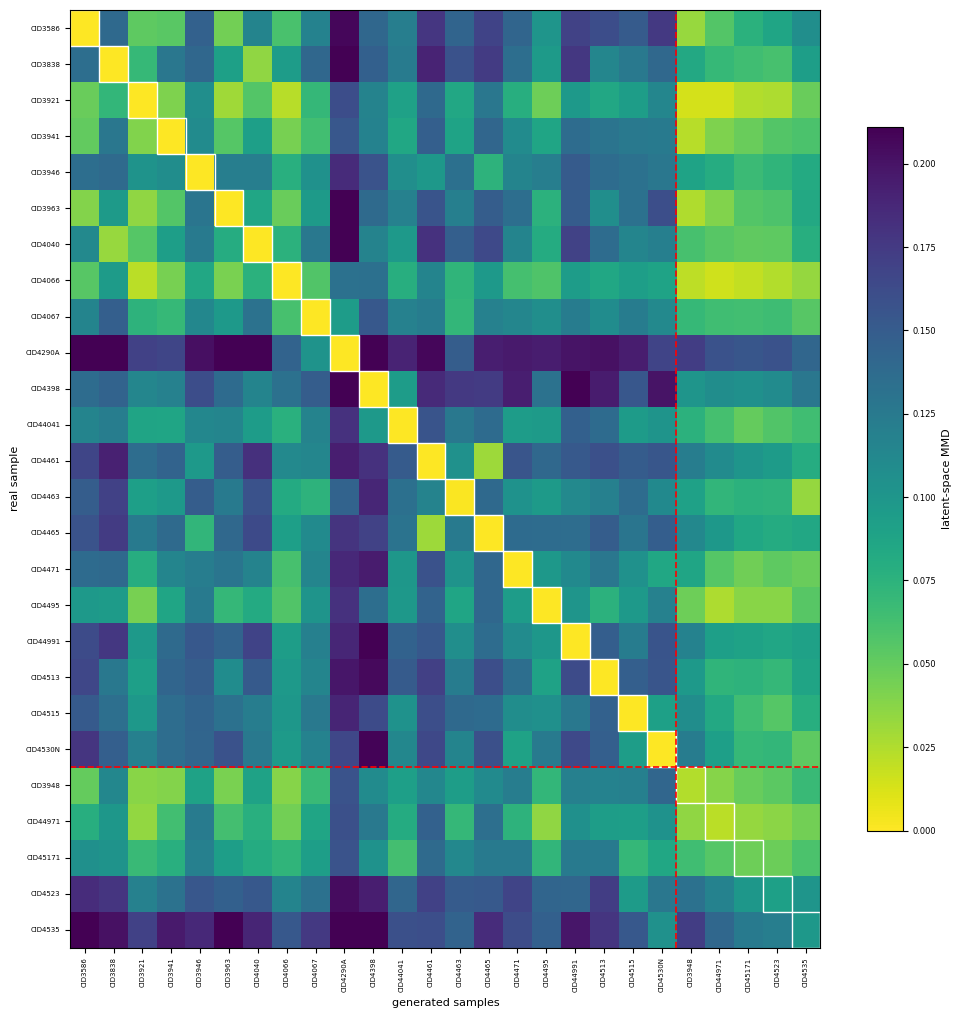

In [11]:
build_single_heatmap(swap_dir / 'cross_mmd_matrix.csv', 'MMD')

## E-distance heatmap

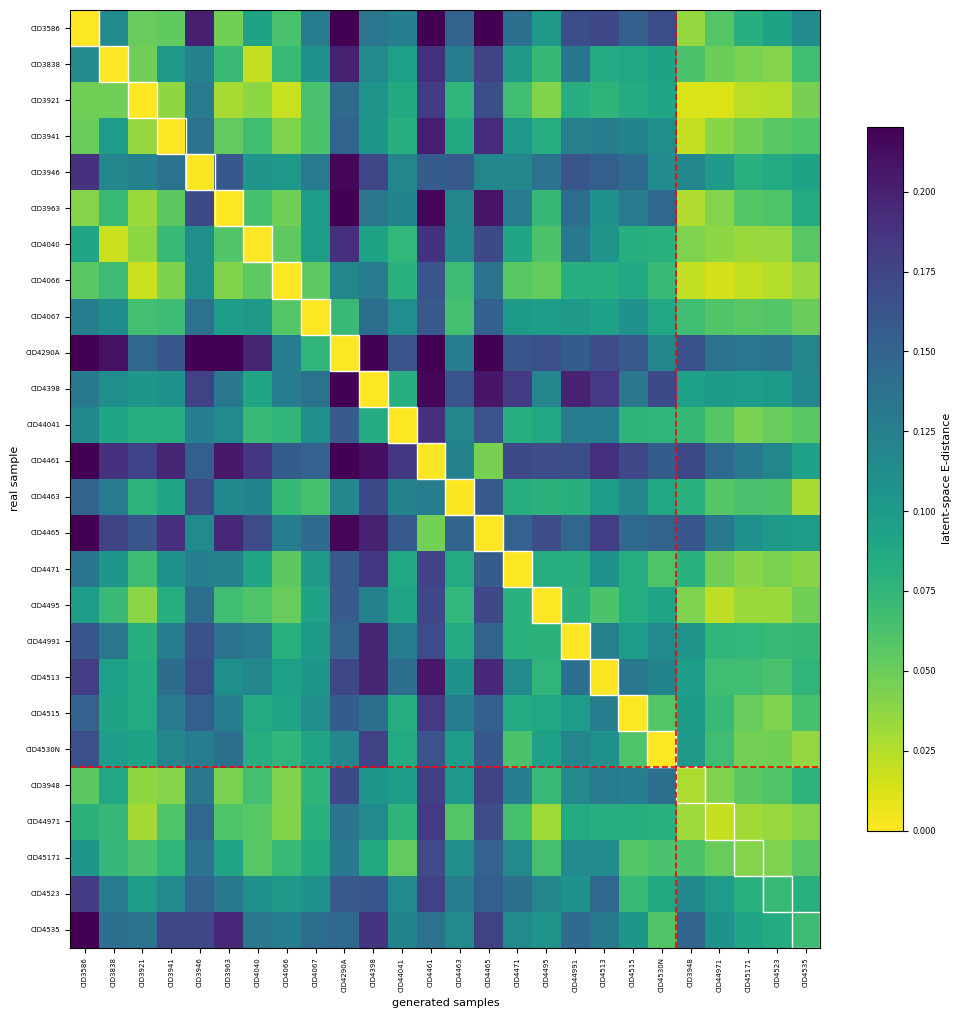

In [12]:
build_single_heatmap(swap_dir / 'cross_mmd_matrix_edist.csv', 'E-distance')